⚡⚡ What is Probability? ⚡⚡

--Probability is the numerical measure of the likelihood that an event will occur. It ranges from 0 to 1, where 0 represents an impossible event and 1 represents a certain event.

P(E)=Total OutcomesFavorable Outcomes​


Key Terminology:

Experiment: Randomly selecting a student.

Outcome: Pass or Fail.

Event: A specific condition such as attendance >80%.

Sample Space: {Pass, Fail}.

Probability: Chance of an event occurring.

Examples of Events:

Student studies more than 10 hours per week.

Student attendance exceeds 80%.

Student passes the final exam.


In [1]:
import pandas as pd
import numpy as np


In [3]:
csv_data = pd.read_csv("Expectation_Decider_Dataset.csv")

In [8]:
df= pd.DataFrame(csv_data)
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,5,51,No,66,Fail
1,9,58,Yes,46,Fail
2,20,77,Yes,38,Fail
3,4,63,Yes,99,Pass
4,2,85,Yes,88,Pass


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   study_hours          200 non-null    int64 
 1   attendance           200 non-null    int64 
 2   group_discussion     200 non-null    object
 3   previous_test_score  200 non-null    int64 
 4   final_exam_pass      200 non-null    object
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


In [11]:
df.shape

(200, 5)

In [12]:
df["final_exam_pass"].value_counts()

final_exam_pass
Pass    109
Fail     91
Name: count, dtype: int64

In [13]:
pass_count=(df['final_exam_pass']=="Pass").sum()
total_student= len(df)
ep_probablity=pass_count/total_student
print(ep_probablity)

0.545


Empirical Probability of Passing

Number of students who passed = 109

Total students = 200

P(Pass) = 109/200

P(Pass) = 0.545

Therefore, the probability that a randomly selected student passes is 54.5%.






**THEORITICAL PROBABLITY!**


Theoretical probability assumes all outcomes are equally likely.

Pass or Fail

Possible outcomes: pass or fail:

Total outcomes = 2

Favorable outcomes =1

therfore, 1/2=0.5 so there is a proabablity that 50% would pass the exam and 50% would fail it
Therefore theoretical probability is 50%.



***RANDOM VARIABLE***

In [14]:
df['final_exam_pass'].value_counts()

final_exam_pass
Pass    109
Fail     91
Name: count, dtype: int64

In [17]:
print("the pass count is:",pass_count)
fail_count=(df['final_exam_pass']=='Fail').sum()
print("the fail count is:",fail_count)

the pass count is: 109
the fail count is: 91


In [24]:
total_student =len(df)
p= pass_count/total_student
f= fail_count/total_student
print("P(PASS):",p)
print("F(FAIL):",f)

P(PASS): 0.545
F(FAIL): 0.455


Let X = Number of students passing among 3 randomly selected students.

Possible values:

X = {0,1,2,3}

In [25]:
p = pass_count/total_student
q = fail_count/total_student

print("Probability of Pass =", p)
print("Probability of Fail =", q)

Probability of Pass = 0.545
Probability of Fail = 0.455


In [29]:
px0=q*q*q
px1=(p*q*q +q*p*q+q*p*p)
px2=(p*p*q,+p*q*p+q*p*p)
px3 = p*p*p
print(px0)
print(px1)
print(px2)
print(px3)




0.09419637500000001
0.36080362500000007
(np.float64(0.135146375), np.float64(0.27029275))
0.16187862500000003


In [30]:
import pandas as pd

distribution = pd.DataFrame({
    "X":[0,1,2,3],
    "P(X)":[px0,px1,px2,px3]
})

distribution

,X,P(X)
0,0,0.094196
1,1,0.360804
2,2,"(0.135146375, 0.27029275)"
3,3,0.161879


****MEAN****

μ=np

In [31]:
n=3
mean =n*p
print("Mean =", round(mean,4))

Mean = 1.635


**VARIANCE**(Variance=np(1−p))

In [32]:
variance = n*p*(1-p)

print("Variance =", round(variance,4))

Variance = 0.7439


**VEN DIAGRAMS**

In [33]:
A = df[df['study_hours'] > 10]

B = df[df['attendance'] > 80]

AB = df[
    (df['study_hours'] > 10)
    &
    (df['attendance'] > 80)
]

print("Study >10:", len(A))
print("Attendance >80:", len(B))
print("Both:", len(AB))

Study >10: 95
Attendance >80: 76
Both: 39


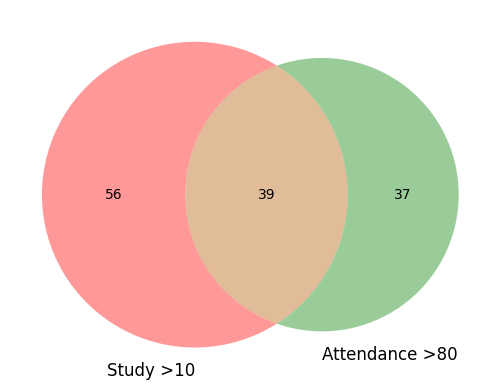

In [35]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

only_A = len(A) - len(AB)
only_B = len(B) - len(AB)
both = len(AB)

venn2(
    subsets=(only_A, only_B, both),
    set_labels=('Study >10','Attendance >80')
)

plt.show()

In [36]:
contingency_table = pd.crosstab(
    df['group_discussion'],
    df['final_exam_pass']
)

print(contingency_table)

final_exam_pass   Fail  Pass
group_discussion            
No                  63    46
Yes                 28    63


In [37]:
joint_probability = len(
    df[
        (df['group_discussion'] == 'Yes')
        &
        (df['final_exam_pass'] == 'Pass')
    ]
) / len(df)

print(joint_probability)

0.315


In [41]:
marginal_probablity = (df['final_exam_pass']== "Pass").mean()
print(marginal_probablity)

0.545


In [ ]:
discussion_students = df[
    df['group_discussion'] == 'Yes'
]

conditional_probability = (
    discussion_students['final_exam_pass'] == 'Pass'
).mean()

print(conditional_probability)

0.6923076923076923


In [48]:
print(marginal_probablity)
print(conditional_probability)

#---------------------#


print(contingency_table)

0.545
0.6923076923076923
final_exam_pass   Fail  Pass
group_discussion            
No                  63    46
Yes                 28    63


In [49]:

P_H_given_Pass = 0.70      
P_H_given_Fail = 0.40     
P_H = 0.60                



P_Pass = (P_H - P_H_given_Fail) / (
    P_H_given_Pass - P_H_given_Fail
)



P_Pass_given_H = (
    P_H_given_Pass * P_Pass
) / P_H

print("P(Pass) =", round(P_Pass,4))

print(
    "P(Pass | High Attendance) =",
    round(P_Pass_given_H,4)
)

print(
    "\nProbability that a student passed "
    "given high attendance =",
    round(P_Pass_given_H*100,2),
    "%"
)

P(Pass) = 0.6667
P(Pass | High Attendance) = 0.7778

Probability that a student passed given high attendance = 77.78 %
